#**Flipkart Laptop Market Analysis Using Web Scraping and Exploratory Data Analysis**  

# **Business Problem Statement**
Customers find it difficult to compare laptops from different brands based on price, specifications, ratings, and discounts available on e-commerce websites. This project helps analyze laptop market trends and customer preferences by collecting and processing laptop data from Flipkart using web scraping and data analysis techniques.



#**Project Objectives**
- Scrape laptop data from Flipkart

- Store data in structured format

- Clean and preprocess the data

- Extract important features

- Perform EDA

- Generate business insights

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings("ignore")
import requests
import re
import time

In [ ]:
productname = []
price = []
rating = []
features = []
pagenum = []
original_price = []
Discount = []
Review = []

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0 Safari/537.36"
}

total_time = time.time()

for i in range(1,106):
    start_time = time.time()

    URL = f"https://www.flipkart.com/search?q=laptop&sid=6bo%2Cb5g&page={i}"

    page = requests.get(URL, headers=headers)   # headers added here
    soup = BeautifulSoup(page.text, "html.parser")

    for x in soup.find_all('div', attrs={'class':'ZFwe0M row'}):
        pname = x.find('div', attrs={'class':'RG5Slk'})
        cost = x.find('div', attrs={'class':'hZ3P6w DeU9vF'})
        rat = x.find('div', attrs={'class':'MKiFS6'})
        specs = x.find('div', attrs={'class':'CMXw7N'})
        op = x.find('div', attrs={'class':'kRYCnD gxR4EY'})
        discount = x.find('div', attrs={'class':'HQe8jr'})
        reviews = x.find('span', attrs={'class':'PvbNMB'})

        productname.append(pname.text if pname else np.nan)
        price.append(cost.text if cost else np.nan)
        rating.append(rat.text if rat else np.nan)
        features.append(specs.text if specs else np.nan)
        original_price.append(op.text if op else np.nan)
        Discount.append(discount.text if discount else np.nan)
        Review.append(reviews.text if reviews else np.nan)

        pagenum.append(i)

    print(f'Page {i} completed in {time.time()-start_time:.2f} seconds')

print("Total Time Completed in seconds", str(time.time()-total_time))



Page 1 completed in 2.25 seconds
Page 2 completed in 0.86 seconds
Page 3 completed in 0.99 seconds
Page 4 completed in 0.82 seconds
Page 5 completed in 0.84 seconds
Page 6 completed in 1.04 seconds
Page 7 completed in 0.83 seconds
Page 8 completed in 0.83 seconds
Page 9 completed in 1.04 seconds
Page 10 completed in 0.94 seconds
Page 11 completed in 0.85 seconds
Page 12 completed in 0.89 seconds
Page 13 completed in 0.84 seconds
Page 14 completed in 1.64 seconds
Page 15 completed in 0.88 seconds
Page 16 completed in 0.80 seconds
Page 17 completed in 0.83 seconds
Page 18 completed in 0.96 seconds
Page 19 completed in 0.82 seconds
Page 20 completed in 0.92 seconds
Page 21 completed in 0.81 seconds
Page 22 completed in 0.86 seconds
Page 23 completed in 0.86 seconds
Page 24 completed in 0.83 seconds
Page 25 completed in 1.66 seconds
Page 26 completed in 0.90 seconds
Page 27 completed in 0.83 seconds
Page 28 completed in 0.82 seconds
Page 29 completed in 1.04 seconds
Page 30 completed in 1.

- Imported required libraries for web scraping and time calculation.
- Created empty lists to store laptop details.
- Added browser headers using **User-Agent** to avoid request blocking.
- Used a loop to scrape data from 105 Flipkart pages.
- Generated dynamic URLs using page numbers.
- Sent HTTP requests to Flipkart using **requests.get()**.
- Parsed HTML content using BeautifulSoup.
- Extracted:
    - **Product Name**
    - **Price**
    - **Rating**
    - **Features**
     -**Original Price**
    - **Discount**
    - **Reviews**
- Stored extracted values into separate lists.
- Handled missing values using **np.nan**.
- Stored **page number** for each product.
- Calculated **execution time** for each page and total scraping process.

In [ ]:
df = pd.DataFrame({
    "Product Name": productname,
    "Price": price,
    "Original Price": original_price,
    "Discount": Discount,
    "Rating": rating,
    "Reviews": Review,
    "Features": features,
    "Page Number": pagenum
})

- The scraped data is converted into a structured dataset for easy analysis.
- Creating a DataFrame prepares the data for cleaning, visualization, and further processing.



In [ ]:
df.to_csv("Laptops.csv",index="True")

In [ ]:
df=pd.read_csv("Laptops.csv")

In [ ]:
df.head()

,Unnamed: 0,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number
0,0,MOTOROLA Motobook 60 Pro Full Metal OLED AI PC...,"₹62,990","₹1,04,990",40% off,4.4,799 Ratings & 119 Reviews,Intel Core Ultra 5 Processor16 GB DDR5 RAM64 b...,1
1,1,Samsung Galaxy Book4 Edge Series Copilot AI-PC...,"₹80,990","₹92,390",12% off,4.4,"3,188 Ratings & 332 Reviews",Snapdragon X Processor16 GB LPDDR5X RAM64 bit ...,1
2,2,Ultimus APEX Intel Celeron Dual Core - (8 GB/5...,"₹24,699","₹39,990",38% off,3.4,122 Ratings & 17 Reviews,Intel Celeron Dual Core Processor8 GB LPDDR4 R...,1
3,3,ASUS Vivobook 15 (2025) with Office 2024 + M36...,"₹40,990","₹50,990",19% off,4.3,"1,241 Ratings & 82 Reviews",Intel Core i3 Processor (13th Gen)8 GB DDR5 RA...,1
4,4,Acer Aspire 3 Intel Pentium Quad Core N6000 - ...,"₹40,990","₹43,999",6% off,3.9,"3,874 Ratings & 290 Reviews",Intel Pentium Quad Core Processor12 GB LPDDR4X...,1


In [ ]:
df.tail()

,Unnamed: 0,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number
979,979,ASUS Intel Core i5 12th Gen - (8 GB/512 GB SSD...,"₹69,195","₹86,999",20% off,NaN,NaN,Intel Core i5 Processor (12th Gen)8 GB DDR4 RA...,41
980,980,HP OMEN AI AMD Ryzen AI 7 Octa Core AI 7 350 -...,"₹1,34,990","₹1,62,996",17% off,4.5,50 Ratings & 5 Reviews,AMD Ryzen AI 7 Octa Core Processor24 GB DDR5 R...,41
981,981,HP Victus Intel Core i5 13th Gen 13420 H - (16...,"₹86,990","₹88,474",1% off,4.3,"1,011 Ratings & 59 Reviews",Intel Core i5 Processor (13th Gen)16 GB DDR4 R...,41
982,982,Acer Aspire Lite AMD Ryzen 5 Hexa Core 5625U -...,"₹58,990","₹66,990",11% off,4.1,"2,945 Ratings & 220 Reviews",AMD Ryzen 5 Hexa Core Processor16 GB DDR4 RAMW...,41
983,983,DELL 15 AMD Ryzen 7 Octa Core 7730U - (16 GB/5...,"₹64,998","₹86,990",25% off,4.1,31 Ratings & 1 Reviews,AMD Ryzen 7 Octa Core Processor16 GB DDR4 RAMW...,41


In [ ]:
df.isnull().sum()

Unnamed: 0         0
Product Name       0
Price              0
Original Price    65
Discount          85
Rating            89
Reviews           89
Features           0
Page Number        0
dtype: int64

**Observations**
- Null values are present in 4 columns: Original Price, Discount, Rating, and Reviews.
- Other columns do not contain missing values.

In [ ]:
df["Rating"]=df["Rating"].fillna(df["Rating"].mode()[0],inplace = True)
df["Original Price"]= df["Original Price"].fillna(df["Original Price"].mode()[0],inplace = True)
df["Discount"]= df["Discount"].fillna(df["Discount"].mode()[0],inplace = True)
df["Reviews"]= df["Reviews"].fillna(df["Reviews"].mode()[0],inplace = True)

- Missing values in Rating, Reviews, Original Price, and Discount columns are filled using mode values.
- The dataset becomes more complete after handling null values.

In [ ]:
df.isnull().sum()

Unnamed: 0        0
Product Name      0
Price             0
Original Price    0
Discount          0
Rating            0
Reviews           0
Features          0
Page Number       0
Original_price    0
Original_Price    0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head(1)

,Unnamed: 0,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number,Original_price,Original_Price
0,0,MOTOROLA Motobook 60 Pro Full Metal OLED AI PC...,"₹62,990","₹1,04,990",40% off,4.4,799 Ratings & 119 Reviews,Intel Core Ultra 5 Processor16 GB DDR5 RAM64 b...,1,"₹1,04,990","₹1,04,990"


In [ ]:
df["Brand"] = df["Product Name"].apply(lambda x: re.findall(r"^\w+",x)[0])

In [ ]:
df.head(1)

,product name,Price,ratings,Features,Page number,Original_price,Discount,Review,Brand
0,DELL 15 AMD Ryzen 5 Hexa Core 7530U - (16 GB/5...,"₹38,990",4.3,AMD Ryzen 5 Hexa Core Processor16 GB DDR4 RAMW...,1,"₹56,919",31% off,"2,013 Ratings & 135 Reviews",DELL


In [ ]:
df["processor"] = df["Features"].apply(lambda x: re.findall(r"^\w+",x)[0])

In [ ]:
df.head(1)

,Unnamed: 0,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number,Original_price,Original_Price,Brand,processor
0,0,MOTOROLA Motobook 60 Pro Full Metal OLED AI PC...,"₹62,990","₹1,04,990",40% off,4.4,799 Ratings & 119 Reviews,Intel Core Ultra 5 Processor16 GB DDR5 RAM64 b...,1,"₹1,04,990","₹1,04,990",MOTOROLA,Intel


In [ ]:
df["Ratings1"] = df["Reviews"].apply(lambda x: re.split(r"[&]",x)[0])

In [ ]:
df["number_of_ratings" ] = df["Ratings1"].apply(lambda x: re.findall(r"[\d,]+",x)[0].replace(",","")).astype("int")

In [ ]:
df["Reviews1"] = df["Reviews"].apply(lambda x: re.split(r"[&]",x)[1])

In [ ]:
df["number_of_reviews"] = df["Reviews1"].apply(lambda x:re.findall(r"[\d,]+",x)[0].replace(",","")).astype("int")

In [ ]:
df.head(1)

,Unnamed: 0,Product Name,Price,Original Price,Discount,Rating,Reviews,Features,Page Number,Original_price,Original_Price,Brand,processor,Ratings1,number_of_ratings,Reviews1,number_of_reviews
0,0,MOTOROLA Motobook 60 Pro Full Metal OLED AI PC...,"₹62,990","₹1,04,990",40% off,4.4,799 Ratings & 119 Reviews,Intel Core Ultra 5 Processor16 GB DDR5 RAM64 b...,1,"₹1,04,990","₹1,04,990",MOTOROLA,Intel,799 Ratings,799,119 Reviews,119


In [ ]:
df["Price"] = df["Price"].apply(lambda x: re.sub(r"[₹,]","",x)).astype("int")

In [ ]:
df["Original_price"] = df["Original_price"].apply(lambda x: re.sub(r"[₹,]","",x)).astype("int")

In [ ]:
df["Discount"] = df["Discount"].apply(lambda x: re.sub(r"[% off]","",x)).astype("int")

In [ ]:
df["Features"][0]

'Intel Core Ultra 5 Processor16 GB DDR5 RAM64 bit Windows 11 Operating System512 GB SSD35.56 cm (14 inch) DisplayOffice Home & Student 20241 Year Onsite Warranty'

In [ ]:
df["GB_List"] = df["Features"].apply(lambda x:re.findall(r"(\d+)\s*(?:GB|TB)",x))

In [ ]:
df["RAM"] = df["GB_List"].apply(lambda x: x[0] if len(x)>0 else np.nan).astype("int")

In [ ]:
df["Storage"] = df["GB_List"].apply(lambda x: x[1] if len(x)>1 else np.nan)

In [ ]:
df["Storage"].isnull().sum()

np.int64(21)

In [ ]:
df["Storage"]= df["Storage"].fillna(df["Storage"].mode()[0],inplace = True)

In [ ]:
df["Storage"] = df["Storage"].astype("int")

In [ ]:
df.columns

Index(['Unnamed: 0', 'Product Name', 'Price', 'Original Price', 'Discount',
       'Rating', 'Reviews', 'Features', 'Page Number', 'Original_price',
       'Original_Price', 'Brand', 'processor', 'Ratings1', 'number_of_ratings',
       'Reviews1', 'number_of_reviews', 'GB_List', 'RAM', 'Storage'],
      dtype='str')

In [ ]:
df.drop(columns = ['Product Name','Features','Reviews','Rating','Ratings1','Reviews1','GB_List'],inplace =  True)

In [ ]:
df.columns

Index(['Unnamed: 0', 'Price', 'Original Price', 'Discount', 'Page Number',
       'Original_price', 'Original_Price', 'Brand', 'processor',
       'number_of_ratings', 'number_of_reviews', 'RAM', 'Storage'],
      dtype='str')

In [ ]:
df

,Unnamed: 0,Price,Original Price,Discount,Page Number,Original_price,Original_Price,Brand,processor,number_of_ratings,number_of_reviews,RAM,Storage
0,0,62990,"₹1,04,990",40,1,104990,"₹1,04,990",MOTOROLA,Intel,799,119,16,512
1,1,80990,"₹92,390",12,1,92390,"₹92,390",Samsung,Snapdragon,3188,332,16,512
2,2,24699,"₹39,990",38,1,39990,"₹39,990",Ultimus,Intel,122,17,8,512
3,3,40990,"₹50,990",19,1,50990,"₹50,990",ASUS,Intel,1241,82,8,512
4,4,40990,"₹43,999",6,1,43999,"₹43,999",Acer,Intel,3874,290,12,512
...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,979,69195,"₹86,999",20,41,86999,"₹86,999",ASUS,Intel,543,43,8,512
980,980,134990,"₹1,62,996",17,41,162996,"₹1,62,996",HP,AMD,50,5,24,1
981,981,86990,"₹88,474",1,41,88474,"₹88,474",HP,Intel,1011,59,16,512
982,982,58990,"₹66,990",11,41,66990,"₹66,990",Acer,AMD,2945,220,16,1


**Observations**

**Using Regex**
- Brand names are extracted from the **Product Name** column using regex.
- Processor details are extracted from the **Features** column.
- Ratings and reviews are separated from the **Reviews** column.
- Numerical values for ratings and reviews are extracted successfully.
- **Price**, **Original Price**, and **Discount** columns are cleaned and converted into numerical format.
- RAM and storage values are extracted from the **Features** column using regex.
- Missing values in the **Storage** column are identified and filled.
- Unnecessary columns are removed to make the dataset clean and analysis-ready.
- Unwanted and temporary preprocessing columns are removed from the dataset.

In [ ]:
df.to_csv("Cleaned_laptops.csv",index = False)

In [ ]:
df = pd.read_csv("/content/Cleaned_laptops.xls")
df

,Unnamed: 0,Price,Original Price,Discount,Page Number,Original_price,Original_Price,Brand,processor,number_of_ratings,number_of_reviews,RAM,Storage
0,0,62990,"₹1,04,990",40,1,104990,"₹1,04,990",MOTOROLA,Intel,799,119,16,512
1,1,80990,"₹92,390",12,1,92390,"₹92,390",Samsung,Snapdragon,3188,332,16,512
2,2,24699,"₹39,990",38,1,39990,"₹39,990",Ultimus,Intel,122,17,8,512
3,3,40990,"₹50,990",19,1,50990,"₹50,990",ASUS,Intel,1241,82,8,512
4,4,40990,"₹43,999",6,1,43999,"₹43,999",Acer,Intel,3874,290,12,512
...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,979,69195,"₹86,999",20,41,86999,"₹86,999",ASUS,Intel,543,43,8,512
980,980,134990,"₹1,62,996",17,41,162996,"₹1,62,996",HP,AMD,50,5,24,1
981,981,86990,"₹88,474",1,41,88474,"₹88,474",HP,Intel,1011,59,16,512
982,982,58990,"₹66,990",11,41,66990,"₹66,990",Acer,AMD,2945,220,16,1


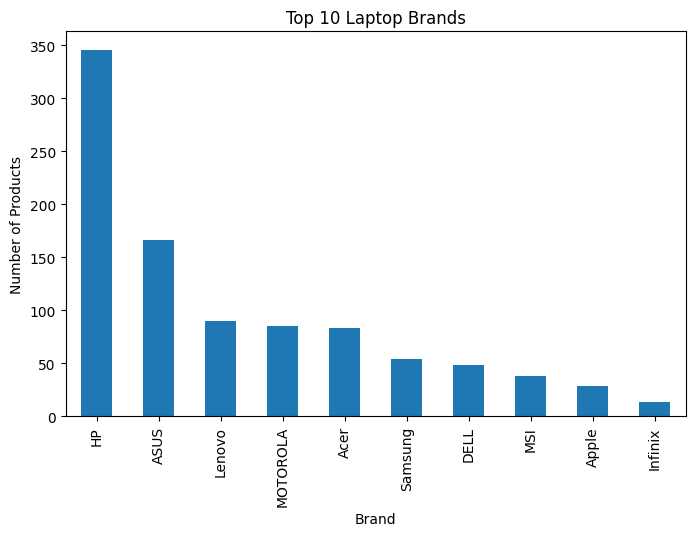

In [ ]:
# 1. Using Univariate Analysis, which laptop brands have the highest number of products?

df["Brand"].value_counts().head(10).plot(kind="bar", figsize=(8,5))
plt.title("Top 10 Laptop Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.show()

**Observations**

- A bar chart is generated for the top 10 laptop brands.


- Brands like HP, ASUS, Lenovo, and Acer have the highest number of products.


- A few brands dominate most of the laptop listings in the dataset.


- Popular laptop brands have a stronger market presence on Flipkart.


- Customers are provided with more choices from leading brands compared to smaller brands.



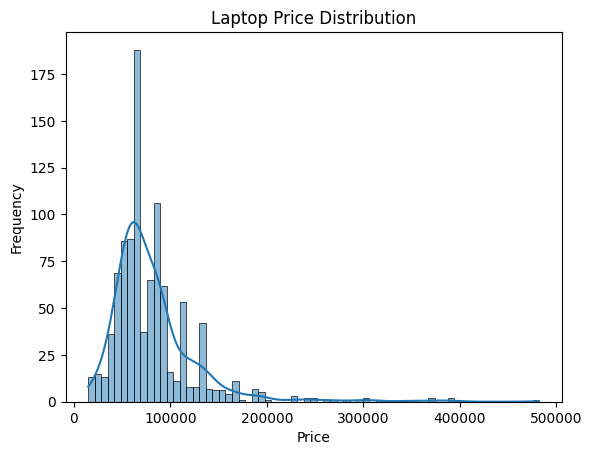

In [ ]:
# 2. Using Histogram and KDE Plot, how are laptop prices distributed?

sns.histplot(df["Price"], kde=True)
plt.title("Laptop Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

**Observations**

- A histogram with KDE curve is generated for the Price column.


- Most laptops are concentrated in the lower and middle price ranges.


- Very few laptops are available in the premium price segment.


- The distribution is positively skewed due to high-priced gaming and premium laptops.


- Budget and mid-range laptops dominate the Flipkart market listings.



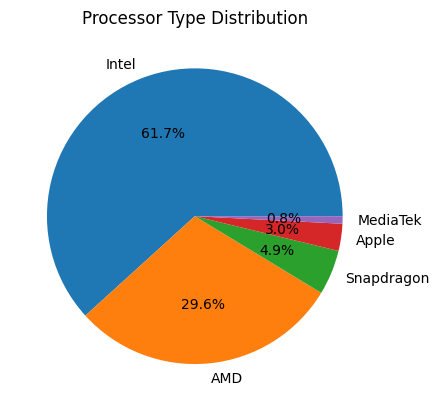

In [ ]:
# 3. Using Pie Chart, which processor type is most commonly used?

df["processor"].value_counts().head(5).plot(kind="pie", autopct="%1.1f%%")
plt.title("Processor Type Distribution")
plt.ylabel("")
plt.show()

**Observations**

- A pie chart is generated to show the distribution of processor types.


- Intel processors occupy the largest share in the dataset.


- AMD processors have a comparatively smaller percentage.


- Intel-based laptops dominate most Flipkart laptop listings.


- The output indicates higher market preference and availability for Intel processors.



In [ ]:
# 4. Using GroupBy Analysis, which brands offer higher and lower average prices?

df.groupby("Brand")["Price"].mean().sort_values(ascending=False)

,Price
Brand,
Apple,190236.206897
GIGABYTE,140990.000000
MICROSOFT,128991.636364
MSI,96363.605263
HP,87096.219653
Samsung,85488.314815
Lenovo,84856.811111
ASUS,80098.246988
DELL,66297.562500


**Observations**

- GroupBy analysis is performed on **Brand** and average **Price**.


- Brands like Apple, MSI, and ASUS have higher average laptop prices.


- Brands such as Avita and Infinix offer lower-priced laptops.


- Premium and gaming brands dominate the higher price segment.


- Budget brands mainly focus on affordable laptops for regular users.



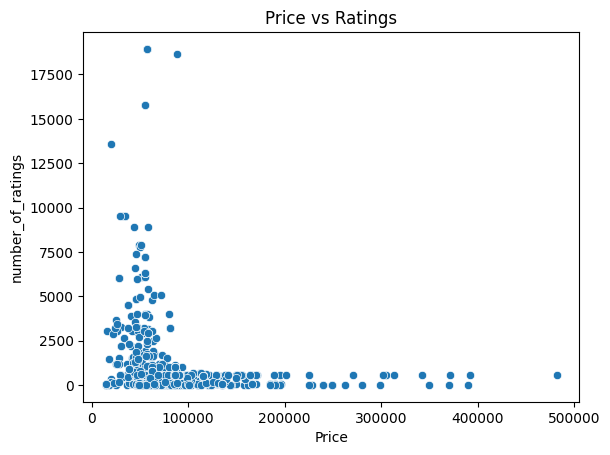

In [ ]:
# 5. Using Scatter Plot, is there a relationship between price and ratings?

sns.scatterplot(x="Price", y="number_of_ratings", data=df)
plt.title("Price vs Ratings")
plt.show()

**Observations**

- A scatter plot is generated between **Price** and **ratings**.

- Most laptops are clustered within the average rating range.

- High-priced laptops do not always have higher ratings.

- No strong linear relationship is observed between price and ratings.

- Customer ratings depend on multiple factors beyond laptop price alone.

In [ ]:
# 6. Using GroupBy Aggregation, which brands receive the highest average ratings?

df.groupby("Brand")["number_of_ratings"].mean().sort_values(ascending=False).head(10)

,number_of_ratings
Brand,
realme,15784.000000
Samsung,6480.092593
WINGS,2307.000000
Acer,1988.843373
Primebook,1491.750000
ASUS,1150.644578
Apple,956.206897
MOTOROLA,808.529412
Lenovo,569.744444


**Observations**

- GroupBy aggregation is performed on Brand and average ratings.

- Some premium brands show higher average customer ratings.

- Brands with balanced pricing and good specifications receive better ratings.

- Budget brands generally have moderate ratings compared to premium brands.

- Customer satisfaction varies across different laptop brands based on performance and features.

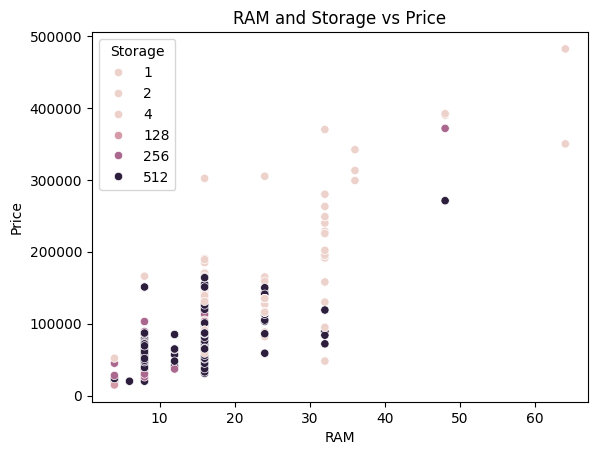

In [ ]:
# 7. Using Scatter Plot Analysis, how do RAM and storage influence laptop pricing?

sns.scatterplot(x="RAM", y="Price", hue="Storage", data=df)
plt.title("RAM and Storage vs Price")
plt.show()

**Observations**

- A scatter plot is generated between RAM, Storage, and Price.


- Laptops with higher RAM and storage generally have higher prices.


- Most budget laptops contain moderate RAM and storage configurations.


- High-end laptops with large RAM and SSD storage appear in the premium price range.


- RAM and storage are important factors influencing laptop pricing in the market.



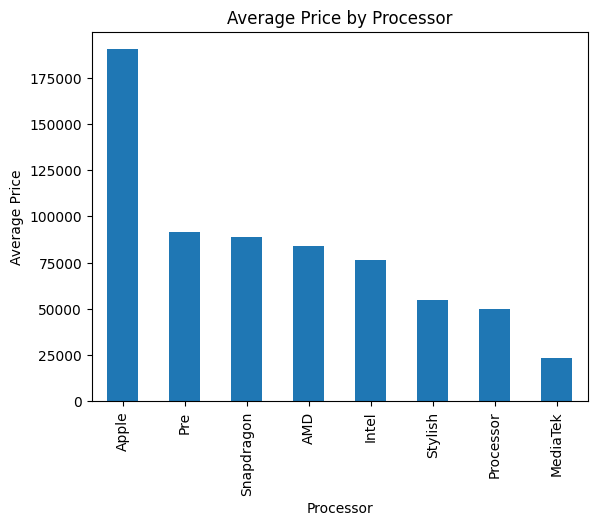

In [ ]:
# 8. Using GroupBy and Bar Chart, which processor types are associated with expensive laptops?

df.groupby("processor")["Price"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Price by Processor")
plt.xlabel("Processor")
plt.ylabel("Average Price")
plt.show()

**Observations**

- A bar chart is generated showing the average price for each processor category.


- Apple processor laptops have the highest average price in the dataset.


- Pre and Snapdragon processor laptops also show comparatively higher average prices.


- AMD and Intel processors fall in the medium price range.


- Mediatek processor laptops have the lowest average prices.


- The output shows that processor type has a strong influence on laptop pricing.



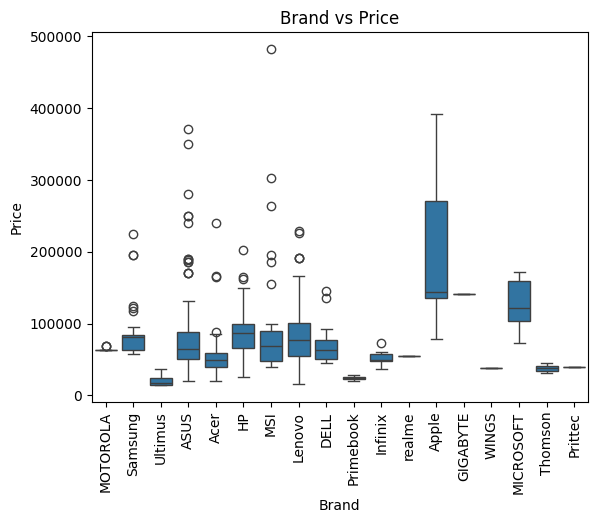

In [ ]:
# 9. Using Boxplot, which brands focus on budget and premium laptops?

sns.boxplot(x="Brand", y="Price", data=df)
plt.xticks(rotation=90)
plt.title("Brand vs Price")
plt.show()

- A boxplot is generated between Brand and Price.

- Apple laptops have the highest price range among all brands.

- MSI and ASUS contain several high-price outliers, indicating premium and gaming laptops.

- HP and Lenovo show wide price distributions because they offer both budget and premium laptops.

- Brands like Ultimus, Thomson, Primebook, and Wings fall mainly in the lower price range.

- The output shows that Apple, MSI, and ASUS focus more on premium laptops, while brands like Ultimus and Thomson target budget users.

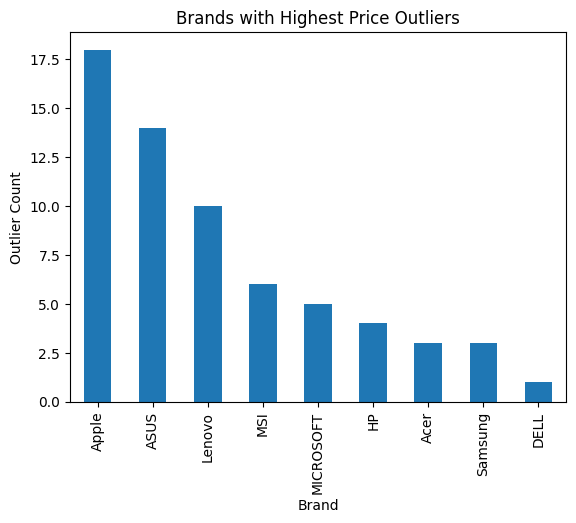

In [ ]:
# 10. Using Outlier Analysis and Bar Chart, which brands contain the highest number of price outliers?

outliers["Brand"].value_counts().plot(kind="bar")
plt.title("Brands with Highest Price Outliers")
plt.xlabel("Brand")
plt.ylabel("Outlier Count")
plt.show()

**Observations**

- A bar chart is generated for brands containing price outliers.


- ASUS has the highest number of price outliers in the dataset.


- Lenovo, HP, and MSI also contain several high-price outlier laptops.


- Brands with gaming and premium laptops contribute more to extreme price values.


- The output indicates that premium and high-performance laptops are concentrated mainly in ASUS, MSI, Lenovo, and HP brands.



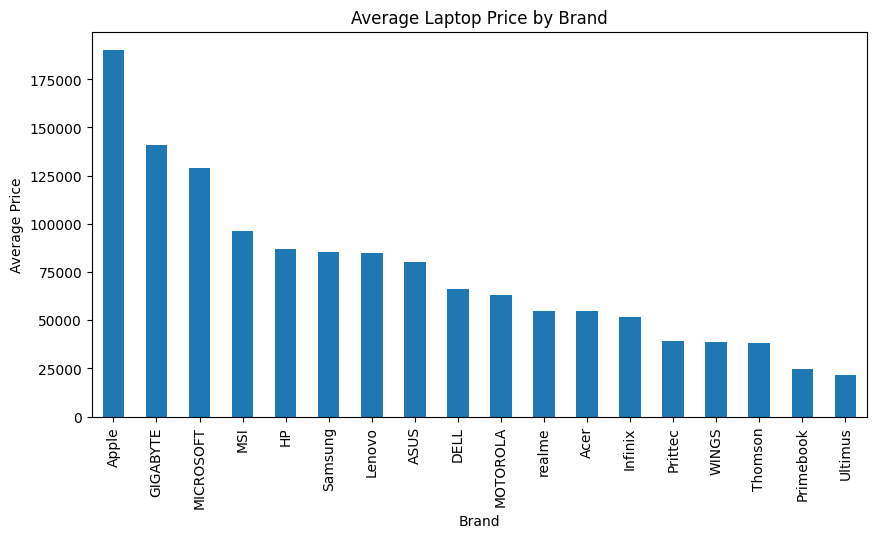

In [ ]:
# 11. Using GroupBy Mean Analysis, what is the average laptop price for each brand?

df.groupby("Brand")["Price"].mean().sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Average Laptop Price by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.show()

**Observations**

- Apple has the highest average laptop price, followed by GIGABYTE and MICROSOFT.


- MSI, HP, Samsung, Lenovo, and ASUS fall in the medium-to-high price range.


- Primebook and Ultimus have the lowest average laptop prices.


- The output shows that premium brands target high-end users, while brands like Ultimus focus on budget customers.




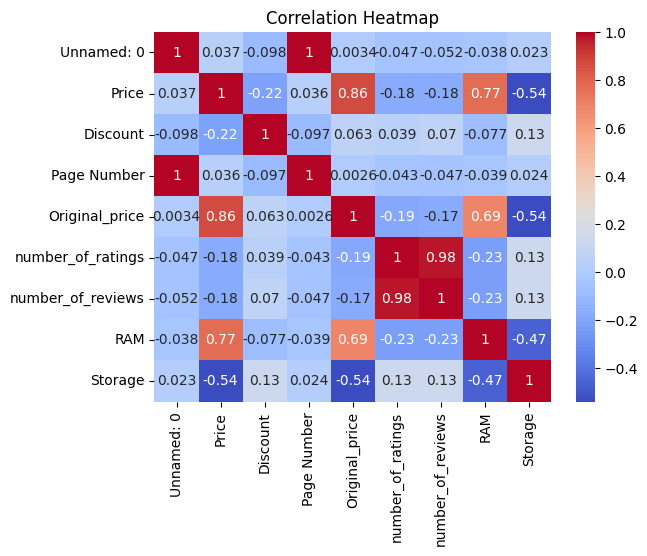

In [ ]:
# 12. Using Correlation Analysis and Heatmap, which numerical features are related to laptop price?

corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Observations**

- A heatmap is generated for numerical feature correlations.


- Price and Original Price show a strong positive correlation.


- RAM and Storage have a moderate positive relationship with laptop prices.


- Ratings and reviews show weaker correlations with price.


- The output indicates that laptop specifications influence pricing more than customer ratings.



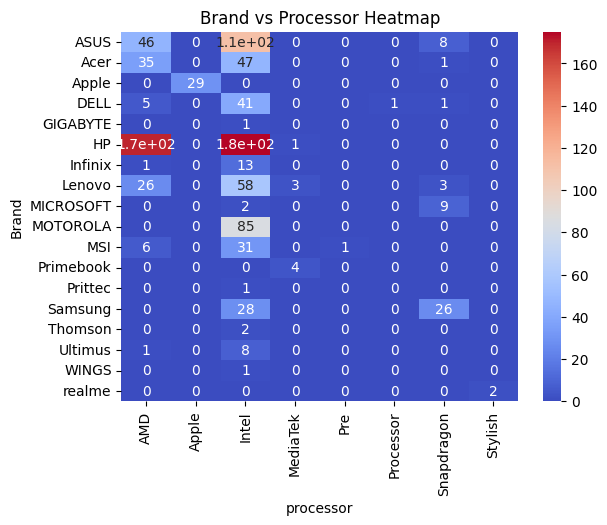

In [ ]:
# 13. Using CrossTab and Heatmap, what is the relationship between brands and processor types?

cross_tab = pd.crosstab(df["Brand"], df["processor"])

sns.heatmap(cross_tab, annot=True, cmap="coolwarm")
plt.title("Brand vs Processor Heatmap")
plt.show()

**Observations**

- A heatmap is generated between Brand and processor.


- Intel processors are used by most laptop brands in the dataset.


- HP, ASUS, and Lenovo contain a higher number of Intel-based laptops.


- AMD processors are comparatively fewer and concentrated in selected brands.


- The output shows that Intel processors dominate the overall laptop market.



In [ ]:
# 14. Using Multivariate Analysis and GroupBy, what market trends can be identified?

df.groupby(["Brand", "processor"])[["Price", "RAM", "Storage"]].mean().sort_values(by="Price", ascending=False)

Price        RAM     Storage
Brand     processor                                       
Apple     Apple       190236.206897  23.034483  282.896552
GIGABYTE  Intel       140990.000000  16.000000    1.000000
MICROSOFT Snapdragon  138101.111111  16.000000  369.888889
MSI       AMD         109528.000000  16.000000  341.833333
          Intel        93977.741935  15.741935  363.774194
Lenovo    AMD          92454.846154  16.615385  413.730769
HP        AMD          92050.182353  18.352941  261.000000
MSI       Pre          91339.000000  16.000000    1.000000
Samsung   Intel        89665.321429  14.285714  366.000000
MICROSOFT Intel        87999.000000   8.000000  256.000000
Lenovo    Intel        85050.155172  15.103448  371.017241
HP        Intel        82632.925714  15.451429  363.080000
Samsung   Snapdragon   80990.000000  16.000000  512.000000
ASUS      Intel        80928.276786  15.392857  429.901786
          AMD          79857.000000  13.043478  389.826087
Lenovo    Snapdragon   79326.666667  16.000000  341.666667
ASUS      Snapdragon   69865.000000  16.000000  512.000000
DELL      Snapdragon   68990.000000  16.000000  512.000000
          Intel        67069.390244  12.097561  437.219512
MOTOROLA  Intel        63201.764706  16.000000  493.964706
DELL      AMD          62691.600000  14.400000  409.800000
Acer      Intel        62034.723404  13.361702  395.063830
          Snapdragon   59990.000000  16.000000  512.000000
Infinix   AMD          59990.000000   8.000000  512.000000
realme    Stylish      54999.000000   8.000000  256.000000
Infinix   Intel        50836.153846  16.615385  354.769231
DELL      Processor    49990.000000   8.000000  512.000000
Acer      AMD          45179.857143  10.514286  460.885714
Prittec   Intel        39052.000000   8.000000  512.000000
WINGS     Intel        38490.000000   8.000000  512.000000
Thomson   Intel        37990.000000  16.000000  512.000000
Ultimus   AMD          29755.000000   8.000000  512.000000
HP        MediaTek     25999.000000   4.000000  512.000000
Primebook MediaTek     24492.250000   6.500000  512.000000
Lenovo    MediaTek     20799.333333   5.333333  512.000000
Ultimus   Intel        20458.125000   5.500000  336.000000

**Observations**

- Apple laptops have the highest average price and RAM configuration.

- GIGABYTE and MICROSOFT laptops also fall in the premium category.

- Intel processors are more commonly used across most brands.

- Higher-priced laptops generally provide higher RAM and storage configurations.

# **Conclusion**


This project solves the problem of comparing laptops on e-commerce platforms by automatically collecting and analyzing laptop data from Flipkart using web scraping and EDA techniques. From the analysis, it was observed that Intel processors dominate most laptop listings, while Apple laptops have the highest average prices. Brands like HP, Lenovo, and ASUS provide laptops in both budget and premium categories, whereas Ultimus and Primebook mainly focus on affordable laptops. The analysis also showed that higher RAM and storage configurations increase laptop prices. These insights help customers understand market trends and choose suitable laptops easily, while also helping businesses analyze pricing strategies and customer preferences effectively.